In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
PARTICIPANT_RATINGS_PATH: Path = Path(
    "../dataset/raw/metadata/participant_ratings.xls"
)

participant_ratings_df: pd.DataFrame = pd.read_excel(
    PARTICIPANT_RATINGS_PATH
)

participant_ratings_df.head()

,Participant_id,Trial,Experiment_id,Start_time,Valence,Arousal,Dominance,Liking,Familiarity
0,1,1,5,1695918,6.96,3.92,7.19,6.05,4.0
1,1,2,18,2714905,7.23,7.15,6.94,8.01,4.0
2,1,3,4,3586768,4.94,6.01,6.12,8.06,4.0
3,1,4,24,4493800,7.04,7.09,8.01,8.22,4.0
4,1,5,20,5362005,8.26,7.91,7.19,8.13,1.0


In [3]:
participant_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_id  1280 non-null   int64  
 1   Trial           1280 non-null   int64  
 2   Experiment_id   1280 non-null   int64  
 3   Start_time      1280 non-null   int64  
 4   Valence         1280 non-null   float64
 5   Arousal         1280 non-null   float64
 6   Dominance       1280 non-null   float64
 7   Liking          1280 non-null   float64
 8   Familiarity     1160 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 90.1 KB


In [4]:
participant_ratings_df.describe()

,Participant_id,Trial,Experiment_id,Start_time,Valence,Arousal,Dominance,Liking,Familiarity
count,1280.000000,1280.000000,1280.000000,1.280000e+03,1280.000000,1280.000000,1280.000000,1280.000000,1160.000000
mean,16.500000,20.500000,20.500000,2.054696e+07,5.254313,5.156711,5.382750,5.518133,2.347414
std,9.236701,11.547908,11.547908,1.052269e+07,2.130816,2.020499,2.096321,2.282780,1.566747
min,1.000000,1.000000,1.000000,1.695918e+06,1.000000,1.000000,1.000000,1.000000,1.000000
25%,8.750000,10.750000,10.750000,1.149579e+07,3.867500,3.762500,3.932500,3.960000,1.000000
50%,16.500000,20.500000,20.500000,2.032845e+07,5.040000,5.230000,5.240000,6.050000,2.000000
75%,24.250000,30.250000,30.250000,2.959904e+07,7.050000,6.950000,7.040000,7.090000,4.000000
max,32.000000,40.000000,40.000000,4.605244e+07,9.000000,9.000000,9.000000,9.000000,5.000000


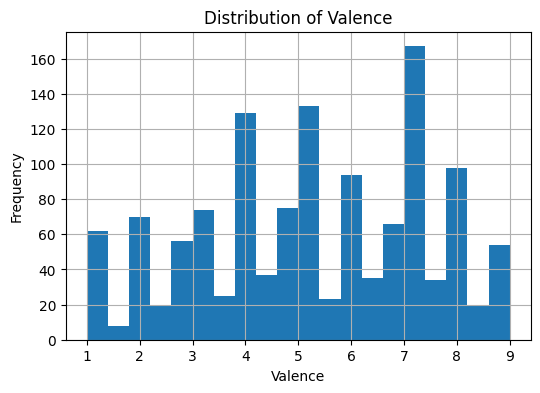

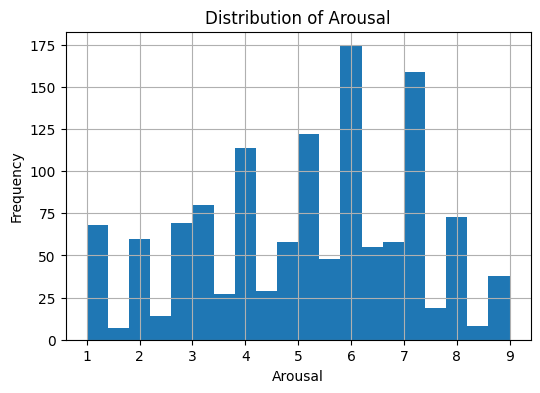

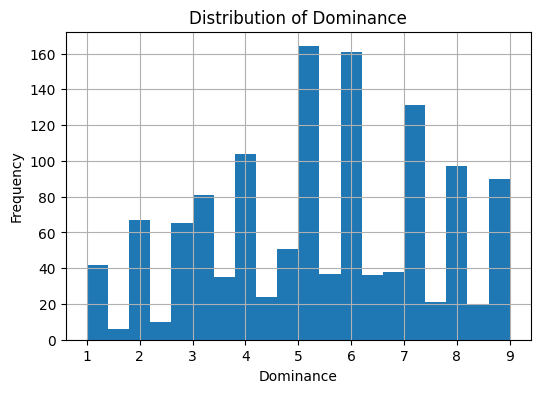

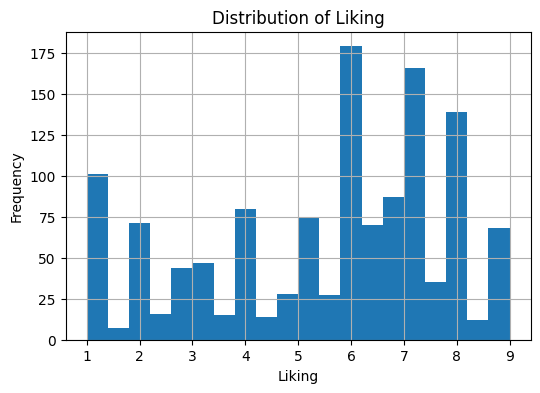

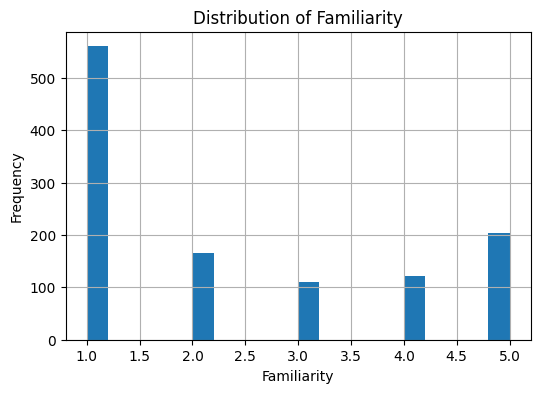

In [5]:
emotion_columns: list[str] = [
    "Valence",
    "Arousal",
    "Dominance",
    "Liking",
    "Familiarity",
]

for column in emotion_columns:

    plt.figure(figsize=(6, 4))

    plt.hist(
        participant_ratings_df[column].dropna(),
        bins=20,
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

In [6]:
correlation_matrix: pd.DataFrame = (
    participant_ratings_df[
        [
            "Valence",
            "Arousal",
            "Dominance",
            "Liking",
            "Familiarity",
        ]
    ]
    .corr(method="pearson")
)

correlation_matrix

,Valence,Arousal,Dominance,Liking,Familiarity
Valence,1.000000,0.150025,0.515982,0.618924,0.316145
Arousal,0.150025,1.000000,0.219145,0.252392,0.180343
Dominance,0.515982,0.219145,1.000000,0.285889,0.118241
Liking,0.618924,0.252392,0.285889,1.000000,0.419596
Familiarity,0.316145,0.180343,0.118241,0.419596,1.000000


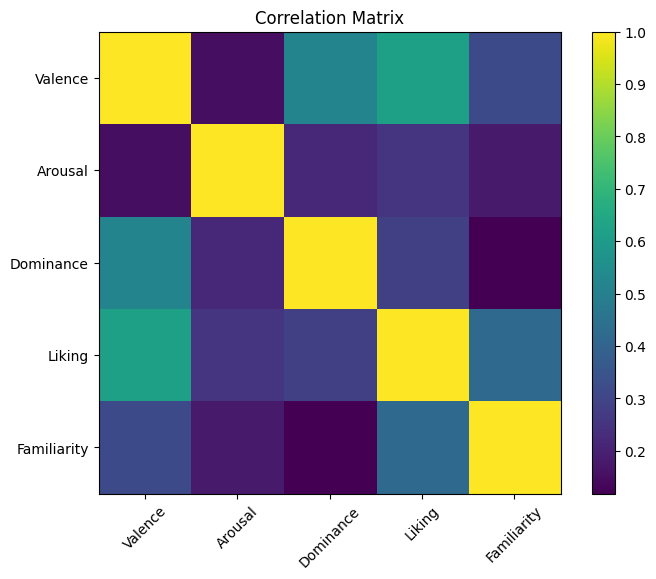

In [7]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")

plt.show()